# TP1 - Protéomique

### 17/09/2025

In [5]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import pandas

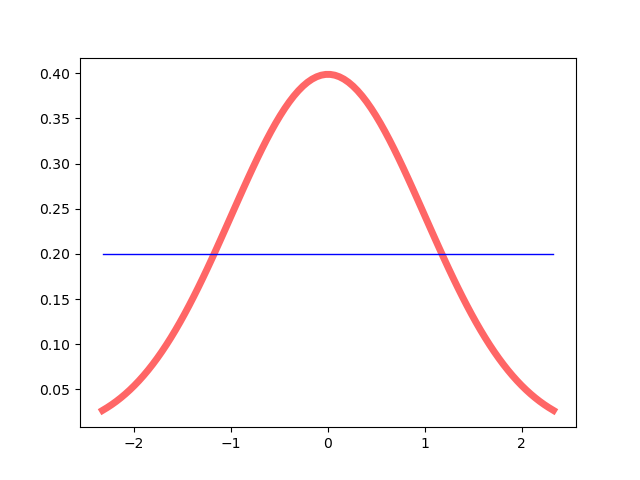

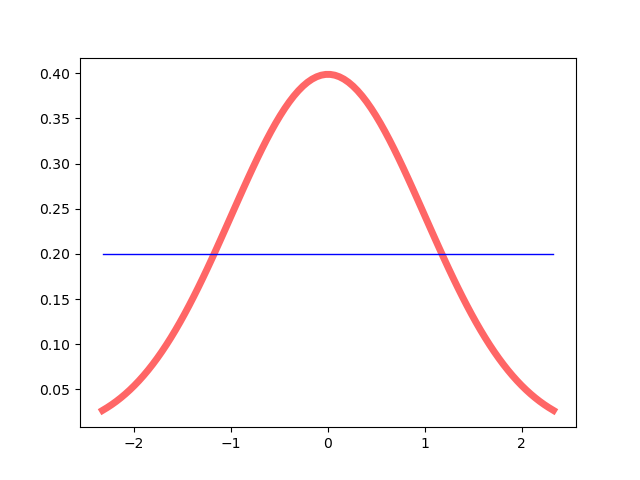

In [7]:
fig, ax = plt.subplots()
x = np.linspace(norm.ppf(0.01),
                norm.ppf(0.99), 100)

ax.plot(x, norm.pdf(x),
       'r-', lw=5, alpha=0.6)

ax.plot(x, np.full(len(x), 0.2),
       'b-', lw=1)

fig.show()

In [13]:
from xml.etree.ElementTree import parse, dump
# Parse the E.Coli proteome XML Document
tree = parse('data/uniprot-proteome_UP000000625.xml')
root = tree.getroot()
ns = '{http://uniprot.org/uniprot}' # MANDATORY PREFIX FOR ANY SEARCH within document
# Store all entries aka proteins in a list of xml nodes
proteins = root.findall(ns + 'entry')
# Display the xml subtree of the first protein 
dump(proteins[0])

<ns0:entry xmlns:ns0="http://uniprot.org/uniprot" dataset="Swiss-Prot" created="1989-10-01" modified="2020-08-12" version="166">
<ns0:accession>P11446</ns0:accession>
<ns0:accession>Q2M8Q3</ns0:accession>
<ns0:name>ARGC_ECOLI</ns0:name>
<ns0:protein>
<ns0:recommendedName>
<ns0:fullName evidence="1 4">N-acetyl-gamma-glutamyl-phosphate reductase</ns0:fullName>
<ns0:shortName evidence="1 4">AGPR</ns0:shortName>
<ns0:ecNumber evidence="1 2">1.2.1.38</ns0:ecNumber>
</ns0:recommendedName>
<ns0:alternativeName>
<ns0:fullName evidence="1 3">N-acetyl-glutamate semialdehyde dehydrogenase</ns0:fullName>
<ns0:shortName evidence="1 3">NAGSA dehydrogenase</ns0:shortName>
</ns0:alternativeName>
</ns0:protein>
<ns0:gene>
<ns0:name type="primary" evidence="1">argC</ns0:name>
<ns0:name type="ordered locus">b3958</ns0:name>
<ns0:name type="ordered locus">JW3930</ns0:name>
</ns0:gene>
<ns0:organism>
<ns0:name type="scientific">Escherichia coli (strain K12)</ns0:name>
<ns0:dbReference type="NCBI Taxonomy" 

In [15]:
# Find the xml subtree of a protein with accession "P31224"
for entry in proteins:
    accessions = entry.findall(ns+"accession")
    for acc in accessions:
        if acc.text == "P31224":
            dump(entry)
            break

<ns0:entry xmlns:ns0="http://uniprot.org/uniprot" dataset="Swiss-Prot" created="1993-07-01" modified="2020-08-12" version="187">
<ns0:accession>P31224</ns0:accession>
<ns0:accession>Q2MBW5</ns0:accession>
<ns0:name>ACRB_ECOLI</ns0:name>
<ns0:protein>
<ns0:recommendedName>
<ns0:fullName>Multidrug efflux pump subunit AcrB</ns0:fullName>
</ns0:recommendedName>
<ns0:alternativeName>
<ns0:fullName>AcrAB-TolC multidrug efflux pump subunit AcrB</ns0:fullName>
</ns0:alternativeName>
<ns0:alternativeName>
<ns0:fullName>Acridine resistance protein B</ns0:fullName>
</ns0:alternativeName>
</ns0:protein>
<ns0:gene>
<ns0:name type="primary">acrB</ns0:name>
<ns0:name type="synonym">acrE</ns0:name>
<ns0:name type="ordered locus">b0462</ns0:name>
<ns0:name type="ordered locus">JW0451</ns0:name>
</ns0:gene>
<ns0:organism>
<ns0:name type="scientific">Escherichia coli (strain K12)</ns0:name>
<ns0:dbReference type="NCBI Taxonomy" id="83333" />
<ns0:lineage>
<ns0:taxon>Bacteria</ns0:taxon>
<ns0:taxon>Proteo

In [101]:
df = pandas.read_csv("data/TCL_wt1.tsv", sep ='\t', na_values="#VALEUR!")

In [103]:
type(df)

pandas.core.frame.DataFrame

In [105]:
df.shape

(2024, 7)

In [107]:
df.head()

,Accession,Description,Gene Symbol,Corrected Abundance ratio (1.53),Log2 Corrected Abundance Ratio,Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT),-LOG10 Adj.P-val
0,P75936,Basal-body rod modification protein FlgD OS=Es...,flgD,0.075817,-3.721335,0.000055,4.260067
1,P76231,Uncharacterized protein YeaC OS=Escherichia co...,yeaC,0.092810,-3.429569,0.000351,3.454627
2,P0A8S9,Flagellar transcriptional regulator FlhD OS=Es...,flhD,0.102614,-3.284695,0.000027,4.571899
3,P0CE48,Elongation factor Tu 2 OS=Escherichia coli (st...,tufB,NaN,NaN,NaN,NaN
4,P05706,PTS system glucitol/sorbitol-specific EIIA com...,srlB,0.108497,-3.204277,0.019963,1.699768


In [109]:
df.tail()

,Accession,Description,Gene Symbol,Corrected Abundance ratio (1.53),Log2 Corrected Abundance Ratio,Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT),-LOG10 Adj.P-val
2019,P24240,6-phospho-beta-glucosidase AscB OS=Escherichia...,ascB,NaN,NaN,NaN,NaN
2020,P0A917,Outer membrane protein X OS=Escherichia coli (...,ompX,1.579739,0.659686,0.002226,2.652391
2021,P02931,Outer membrane protein F OS=Escherichia coli (...,ompF,1.754902,0.811390,0.000068,4.164956
2022,P0AB40,Multiple stress resistance protein BhsA OS=Esc...,bhsA,1.798039,0.846424,0.035928,1.444561
2023,P76042,Putative ABC transporter periplasmic-binding p...,ycjN,NaN,NaN,NaN,NaN


In [111]:
df.columns

Index(['Accession', 'Description', 'Gene Symbol',
       'Corrected Abundance ratio (1.53)', 'Log2 Corrected Abundance Ratio',
       'Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT)',
       '-LOG10 Adj.P-val'],
      dtype='object')

In [113]:
df.dtypes

Accession                                                        object
Description                                                      object
Gene Symbol                                                      object
Corrected Abundance ratio (1.53)                                float64
Log2 Corrected Abundance Ratio                                  float64
Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT)    float64
-LOG10 Adj.P-val                                                float64
dtype: object

In [115]:
df.info

<bound method DataFrame.info of      Accession                                        Description Gene Symbol  \
0       P75936  Basal-body rod modification protein FlgD OS=Es...        flgD   
1       P76231  Uncharacterized protein YeaC OS=Escherichia co...        yeaC   
2       P0A8S9  Flagellar transcriptional regulator FlhD OS=Es...        flhD   
3       P0CE48  Elongation factor Tu 2 OS=Escherichia coli (st...        tufB   
4       P05706  PTS system glucitol/sorbitol-specific EIIA com...        srlB   
...        ...                                                ...         ...   
2019    P24240  6-phospho-beta-glucosidase AscB OS=Escherichia...        ascB   
2020    P0A917  Outer membrane protein X OS=Escherichia coli (...        ompX   
2021    P02931  Outer membrane protein F OS=Escherichia coli (...        ompF   
2022    P0AB40  Multiple stress resistance protein BhsA OS=Esc...        bhsA   
2023    P76042  Putative ABC transporter periplasmic-binding p...        ycjN

In [117]:
df.describe()

,Corrected Abundance ratio (1.53),Log2 Corrected Abundance Ratio,Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT),-LOG10 Adj.P-val
count,1892.000000,1892.000000,1.750000e+03,1750.000000
mean,0.668382,-0.646713,8.238311e-01,0.383981
std,0.184241,0.467234,3.506349e-01,1.066602
min,0.075817,-3.721335,1.034030e-08,0.000000
25%,0.560784,-0.834482,1.000000e+00,0.000000
50%,0.693791,-0.527427,1.000000e+00,0.000000
75%,0.778595,-0.361056,1.000000e+00,0.000000
max,1.798039,0.846424,1.000000e+00,7.985468


In [119]:
df.dropna()

,Accession,Description,Gene Symbol,Corrected Abundance ratio (1.53),Log2 Corrected Abundance Ratio,Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT),-LOG10 Adj.P-val
0,P75936,Basal-body rod modification protein FlgD OS=Es...,flgD,0.075817,-3.721335,0.000055,4.260067
1,P76231,Uncharacterized protein YeaC OS=Escherichia co...,yeaC,0.092810,-3.429569,0.000351,3.454627
2,P0A8S9,Flagellar transcriptional regulator FlhD OS=Es...,flhD,0.102614,-3.284695,0.000027,4.571899
4,P05706,PTS system glucitol/sorbitol-specific EIIA com...,srlB,0.108497,-3.204277,0.019963,1.699768
5,P29744,Flagellar hook-associated protein 3 OS=Escheri...,flgL,0.124183,-3.009460,0.036746,1.434787
...,...,...,...,...,...,...,...
2011,P77330,Prophage lipoprotein Bor homolog OS=Escherichi...,borD,1.535948,0.619129,0.310725,0.507623
2016,P02930,Outer membrane protein TolC OS=Escherichia col...,tolC,1.552288,0.634396,0.013373,1.873757
2020,P0A917,Outer membrane protein X OS=Escherichia coli (...,ompX,1.579739,0.659686,0.002226,2.652391
2021,P02931,Outer membrane protein F OS=Escherichia coli (...,ompF,1.754902,0.811390,0.000068,4.164956


In [121]:
values = df[['Description', 'Gene Symbol']]

In [123]:
type(values)

pandas.core.frame.DataFrame

In [125]:
values.info

<bound method DataFrame.info of                                             Description Gene Symbol
0     Basal-body rod modification protein FlgD OS=Es...        flgD
1     Uncharacterized protein YeaC OS=Escherichia co...        yeaC
2     Flagellar transcriptional regulator FlhD OS=Es...        flhD
3     Elongation factor Tu 2 OS=Escherichia coli (st...        tufB
4     PTS system glucitol/sorbitol-specific EIIA com...        srlB
...                                                 ...         ...
2019  6-phospho-beta-glucosidase AscB OS=Escherichia...        ascB
2020  Outer membrane protein X OS=Escherichia coli (...        ompX
2021  Outer membrane protein F OS=Escherichia coli (...        ompF
2022  Multiple stress resistance protein BhsA OS=Esc...        bhsA
2023  Putative ABC transporter periplasmic-binding p...        ycjN

[2024 rows x 2 columns]>

In [127]:
#values.dtypes() ne fonctionne pas ici
values.describe()

,Description,Gene Symbol
count,2024,2017
unique,2024,2015
top,Basal-body rod modification protein FlgD OS=Es...,rlmC; rlmD
freq,1,2


In [139]:
df.head()

,Accession,Description,Gene Symbol,Corrected Abundance ratio (1.53),Log2 Corrected Abundance Ratio,Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT),-LOG10 Adj.P-val
0,P75936,Basal-body rod modification protein FlgD OS=Es...,flgD,0.075817,-3.721335,0.000055,4.260067
1,P76231,Uncharacterized protein YeaC OS=Escherichia co...,yeaC,0.092810,-3.429569,0.000351,3.454627
2,P0A8S9,Flagellar transcriptional regulator FlhD OS=Es...,flhD,0.102614,-3.284695,0.000027,4.571899
3,P0CE48,Elongation factor Tu 2 OS=Escherichia coli (st...,tufB,NaN,NaN,NaN,NaN
4,P05706,PTS system glucitol/sorbitol-specific EIIA com...,srlB,0.108497,-3.204277,0.019963,1.699768


In [137]:
df.iloc[:, -1]

0       4.260067
1       3.454627
2       4.571899
3            NaN
4       1.699768
          ...   
2019         NaN
2020    2.652391
2021    4.164956
2022    1.444561
2023         NaN
Name: -LOG10 Adj.P-val, Length: 2024, dtype: float64

In [141]:
df.iloc[0:4, [0,2,3]]

,Accession,Gene Symbol,Corrected Abundance ratio (1.53)
0,P75936,flgD,0.075817
1,P76231,yeaC,0.092810
2,P0A8S9,flhD,0.102614
3,P0CE48,tufB,NaN


In [147]:
pandas.read_csv('data/TCL_wt1.tsv', sep="\t", na_values="#VALEUR!", dtype = {'Accession': str, 'Description': str, 'Gene Symbol': str, 
                                                 'Corrected Abundance ratio (1.53)': float,  'Log2 Corrected Abundance Ratio': float, 
                                                 'Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT)': float, '-LOG10 Adj.P-val': float})

,Accession,Description,Gene Symbol,Corrected Abundance ratio (1.53),Log2 Corrected Abundance Ratio,Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT),-LOG10 Adj.P-val
0,P75936,Basal-body rod modification protein FlgD OS=Es...,flgD,0.075817,-3.721335,0.000055,4.260067
1,P76231,Uncharacterized protein YeaC OS=Escherichia co...,yeaC,0.092810,-3.429569,0.000351,3.454627
2,P0A8S9,Flagellar transcriptional regulator FlhD OS=Es...,flhD,0.102614,-3.284695,0.000027,4.571899
3,P0CE48,Elongation factor Tu 2 OS=Escherichia coli (st...,tufB,NaN,NaN,NaN,NaN
4,P05706,PTS system glucitol/sorbitol-specific EIIA com...,srlB,0.108497,-3.204277,0.019963,1.699768
...,...,...,...,...,...,...,...
2019,P24240,6-phospho-beta-glucosidase AscB OS=Escherichia...,ascB,NaN,NaN,NaN,NaN
2020,P0A917,Outer membrane protein X OS=Escherichia coli (...,ompX,1.579739,0.659686,0.002226,2.652391
2021,P02931,Outer membrane protein F OS=Escherichia coli (...,ompF,1.754902,0.811390,0.000068,4.164956
2022,P0AB40,Multiple stress resistance protein BhsA OS=Esc...,bhsA,1.798039,0.846424,0.035928,1.444561


In [149]:
df = df.astype({'Log2 Corrected Abundance Ratio': float, '-LOG10 Adj.P-val': float } )

In [151]:
pandas.read_csv('data/TCL_wt1.tsv', sep="\t", na_values="#VALEUR!")

,Accession,Description,Gene Symbol,Corrected Abundance ratio (1.53),Log2 Corrected Abundance Ratio,Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT),-LOG10 Adj.P-val
0,P75936,Basal-body rod modification protein FlgD OS=Es...,flgD,0.075817,-3.721335,0.000055,4.260067
1,P76231,Uncharacterized protein YeaC OS=Escherichia co...,yeaC,0.092810,-3.429569,0.000351,3.454627
2,P0A8S9,Flagellar transcriptional regulator FlhD OS=Es...,flhD,0.102614,-3.284695,0.000027,4.571899
3,P0CE48,Elongation factor Tu 2 OS=Escherichia coli (st...,tufB,NaN,NaN,NaN,NaN
4,P05706,PTS system glucitol/sorbitol-specific EIIA com...,srlB,0.108497,-3.204277,0.019963,1.699768
...,...,...,...,...,...,...,...
2019,P24240,6-phospho-beta-glucosidase AscB OS=Escherichia...,ascB,NaN,NaN,NaN,NaN
2020,P0A917,Outer membrane protein X OS=Escherichia coli (...,ompX,1.579739,0.659686,0.002226,2.652391
2021,P02931,Outer membrane protein F OS=Escherichia coli (...,ompF,1.754902,0.811390,0.000068,4.164956
2022,P0AB40,Multiple stress resistance protein BhsA OS=Esc...,bhsA,1.798039,0.846424,0.035928,1.444561


In [153]:
df.loc[(df['-LOG10 Adj.P-val'] > 0 )  & (df['Log2 Corrected Abundance Ratio'] > 0.0 ) ]

,Accession,Description,Gene Symbol,Corrected Abundance ratio (1.53),Log2 Corrected Abundance Ratio,Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT),-LOG10 Adj.P-val
1938,P68919,50S ribosomal protein L25 OS=Escherichia coli ...,rplY,1.010458,0.015009,2.035974e-01,0.691228
1939,P0ACG1,DNA-binding protein StpA OS=Escherichia coli (...,stpA,1.013072,0.018737,1.936673e-01,0.712944
1940,P0A903,Outer membrane protein assembly factor BamC OS...,bamC,1.020915,0.029863,3.957145e-01,0.402618
1945,P0ADE4,Translocation and assembly module subunit TamA...,tamA; ytfM,1.024183,0.034474,2.625522e-03,2.580784
1946,P02943,Maltoporin OS=Escherichia coli (strain K12) OX...,lamB,1.030065,0.042736,3.135847e-03,2.503645
1947,P77774,Outer membrane protein assembly factor BamB OS...,bamB,1.035294,0.050041,4.857703e-01,0.313569
1948,P0A940,Outer membrane protein assembly factor BamA OS...,bamA,1.039869,0.056402,1.228502e-01,0.910624
1955,P0AEQ1,Protein GlcG OS=Escherichia coli (strain K12) ...,glcG,1.050327,0.070838,2.177041e-02,1.662133
1957,P09169,Protease 7 OS=Escherichia coli (strain K12) OX...,ompT,1.052288,0.073529,1.085198e-01,0.964491
1962,P05825,Ferrienterobactin receptor OS=Escherichia coli...,fepA,1.076471,0.106309,1.524348e-02,1.816916


In [155]:
df.loc[ df['Gene Symbol'].isin(['fadR', 'arcA'] ) ]

,Accession,Description,Gene Symbol,Corrected Abundance ratio (1.53),Log2 Corrected Abundance Ratio,Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT),-LOG10 Adj.P-val
1862,P0A8V6,Fatty acid metabolism regulator protein OS=Esc...,fadR,0.901307,-0.149909,0.000351,3.454627
1898,P0A9Q1,Aerobic respiration control protein ArcA OS=Es...,arcA,0.931373,-0.102570,0.000136,3.866640


In [262]:
df = pandas.read_csv('data/TCL_wt1.tsv', sep="\t", na_values="#VALEUR!")

In [264]:
df.dtypes

Accession                                                        object
Description                                                      object
Gene Symbol                                                      object
Corrected Abundance ratio (1.53)                                float64
Log2 Corrected Abundance Ratio                                  float64
Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT)    float64
-LOG10 Adj.P-val                                                float64
dtype: object

In [266]:
df = df.dropna()

In [268]:
df = df.astype({'Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT)': float})

In [270]:
df.dtypes

Accession                                                        object
Description                                                      object
Gene Symbol                                                      object
Corrected Abundance ratio (1.53)                                float64
Log2 Corrected Abundance Ratio                                  float64
Abundance Ratio Adj. P-Value: (127. T3 Tc WT) / (126. T0 WT)    float64
-LOG10 Adj.P-val                                                float64
dtype: object

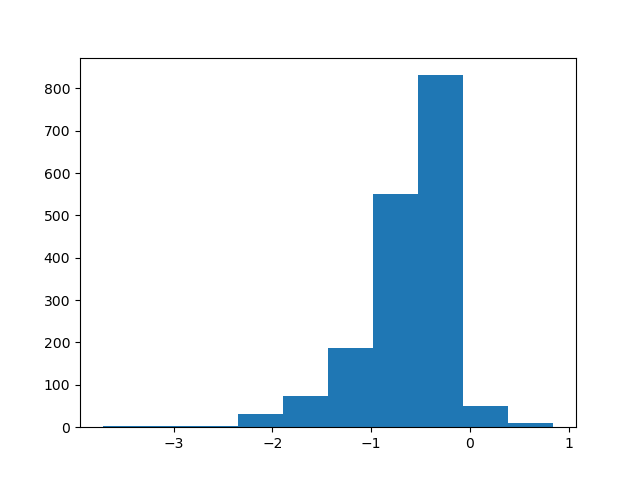

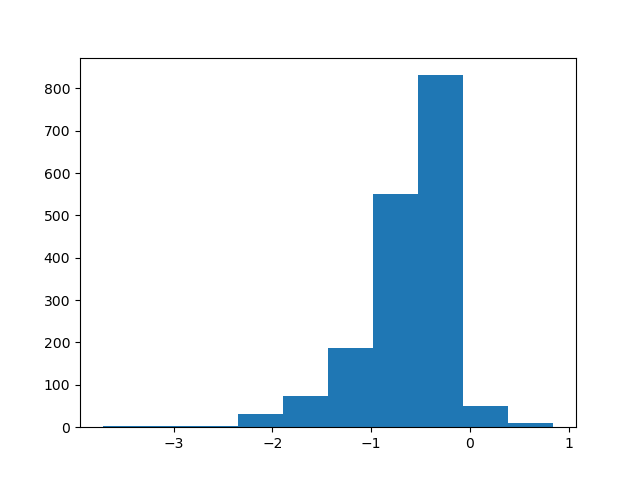

In [272]:
fig, ax = plt.subplots()
ax.hist(df.iloc[:, 4])
fig.show()

In [279]:
mu = np.mean(df.iloc[:, 4])
sigma = np.std(df.iloc[:, 4])
mu, sigma

(-0.63862621564433, 0.47062451611275236)

In [276]:
df.shape

(1746, 7)

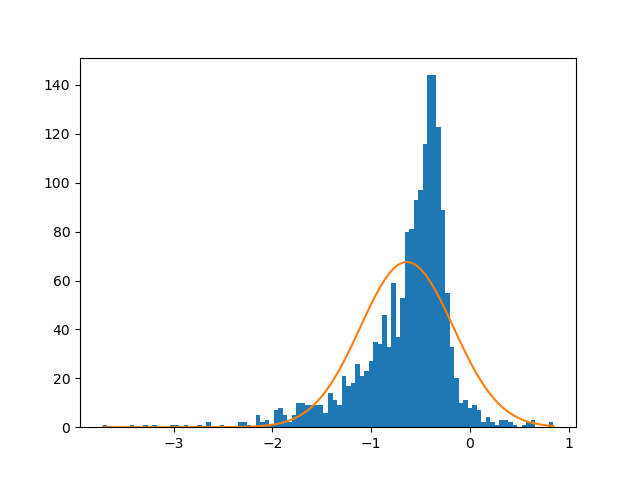

In [283]:
# _ est le vecteur des valeurs d'abondance
fig, ax = plt.subplots()
hist = ax.hist(df.iloc[:, 4], bins=100) # draw histogram
x = np.linspace(min(df.iloc[:, 4]), max(df.iloc[:, 4]), 100) # generate PDF domain points
dx = hist[1][1] - hist[1][0] # Get single value bar height
scale = len(df.iloc[:, 4])*dx # scale accordingly
ax.plot(x, norm.pdf(x, mu, sigma)*scale) # compute theoritical PDF and draw it